<a href="https://colab.research.google.com/github/Hayat-array/Hayat_Ali_JECRC_Foundation_CEI/blob/main/Week6_Hayat_Ali_CEI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 28.6M/28.6M [00:00<00:00, 134MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/mnist-dataset/versions/1


## Understanding Autoencoders for Image Denoising

### What is an Autoencoder?
An Autoencoder is a type of artificial neural network used to learn efficient data codings (representations) in an unsupervised manner. The network is designed to reconstruct its input, meaning it learns a compressed representation (encoding) of the input data and then reconstructs the original input from this compressed representation (decoding).

An Autoencoder typically consists of two main parts:
1.  **Encoder**: This part compresses the input into a lower-dimensional latent-space representation (feature vector). It learns to extract the most important features from the input.
2.  **Decoder**: This part reconstructs the input from the latent-space representation. It learns to generate the original data from the compressed features.

### Why are Autoencoders used for Denoising?
Autoencoders are particularly effective for denoising tasks because they can be trained to learn a 'clean' representation of data from noisy input. When trained on noisy images as input and clean images as target output, the autoencoder learns to map the noisy input to its underlying clean structure. This process encourages the encoder to focus on the essential features of the image, discarding the noise during the compression phase, and then the decoder reconstructs the image from these clean features.

In essence, a denoising autoencoder forces the model to learn a robust representation that captures the fundamental characteristics of the data, filtering out random perturbations.



## 1. Data Preprocessing

First, we'll load the MNIST dataset. If the `kagglehub` download fails, we'll use `tf.keras.datasets.mnist`. Then, we will normalize the images, resize them if necessary, add Gaussian noise, and finally split the data into training, validation, and test sets. We'll also visualize some examples to see the effect of the noise.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Define image dimensions
IMG_WIDTH = 28
IMG_HEIGHT = 28
IMG_CHANNELS = 1

# Global variable to store the dataset path from kagglehub
dataset_path = Path(path)

def load_mnist_data(dataset_path, img_width, img_height):
    # Try loading from kagglehub path first
    try:
        print(f"Attempting to load MNIST from kagglehub path: {dataset_path}")

        # MNIST dataset from kagglehub is usually split into train/test CSVs or similar structure.
        # Let's assume the files are 'train.csv' and 'test.csv' inside the downloaded path.
        # If the structure is different, this part might need adjustment based on inspection.

        # For MNIST from awsaf49/mnist-dataset, it provides `mnist_train.csv` and `mnist_test.csv`.
        train_csv_path = dataset_path / 'mnist_train.csv'
        test_csv_path = dataset_path / 'mnist_test.csv'

        if not train_csv_path.exists() or not test_csv_path.exists():
            raise FileNotFoundError(f"Expected MNIST CSVs not found in {dataset_path}")

        train_df = pd.read_csv(train_csv_path)
        test_df = pd.read_csv(test_csv_path)

        # The first column is 'label', the rest are pixel values
        x_train = train_df.iloc[:, 1:].values.reshape(-1, img_width, img_height, img_channels).astype('float32')
        y_train = train_df.iloc[:, 0].values
        x_test = test_df.iloc[:, 1:].values.reshape(-1, img_width, img_height, img_channels).astype('float32')
        y_test = test_df.iloc[:, 0].values

        print(f"Successfully loaded MNIST from kagglehub path: {dataset_path}")
        return (x_train, y_train), (x_test, y_test)

    except Exception as e:
        print(f"Failed to load MNIST from kagglehub path: {e}. Falling back to TensorFlow MNIST.")
        # Fallback to TensorFlow MNIST if kagglehub loading fails
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

        # Add channel dimension if not present (for grayscale images)
        x_train = np.expand_dims(x_train, -1) if x_train.ndim == 3 else x_train
        x_test = np.expand_dims(x_test, -1) if x_test.ndim == 3 else x_test

        return (x_train, y_train), (x_test, y_test)

# Load the dataset
(x_train, y_train), (x_test, y_test) = load_mnist_data(dataset_path, IMG_WIDTH, IMG_HEIGHT)

# Normalize images to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Resize if necessary (MNIST is already 28x28, but for generality)
# If you were to resize, you'd use tf.image.resize
# x_train = tf.image.resize(x_train, [TARGET_IMG_WIDTH, TARGET_IMG_HEIGHT])
# x_test = tf.image.resize(x_test, [TARGET_IMG_WIDTH, TARGET_IMG_HEIGHT])

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")


Attempting to load MNIST from kagglehub path: /root/.cache/kagglehub/datasets/awsaf49/mnist-dataset/versions/1
Failed to load MNIST from kagglehub path: Expected MNIST CSVs not found in /root/.cache/kagglehub/datasets/awsaf49/mnist-dataset/versions/1. Falling back to TensorFlow MNIST.
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [3]:
import pandas as pd # Import pandas here as it's used in load_mnist_data function

def add_gaussian_noise(images, noise_factor=0.2):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)  # Clip values to stay within [0, 1]
    return noisy_images

# Add Gaussian noise to training and test images
noise_factor = 0.5 # Configurable noise factor
x_train_noisy = add_gaussian_noise(x_train, noise_factor)
x_test_noisy = add_gaussian_noise(x_test, noise_factor)

print(f"x_train_noisy shape: {x_train_noisy.shape}")
print(f"x_test_noisy shape: {x_test_noisy.shape}")


x_train_noisy shape: (60000, 28, 28, 1)
x_test_noisy shape: (10000, 28, 28, 1)


### Create Training, Validation, and Test Sets

We will split the original training data into training and validation sets to monitor model performance during training. The `x_test` data will serve as our independent test set.

In [4]:
from sklearn.model_selection import train_test_split

# Use a portion of the training data for validation
x_train_clean, x_val_clean, x_train_noisy, x_val_noisy = train_test_split(
    x_train, x_train_noisy, test_size=0.2, random_state=42
)

print(f"Training set (clean): {x_train_clean.shape}")
print(f"Training set (noisy): {x_train_noisy.shape}")
print(f"Validation set (clean): {x_val_clean.shape}")
print(f"Validation set (noisy): {x_val_noisy.shape}")
print(f"Test set (clean): {x_test.shape}")
print(f"Test set (noisy): {x_test_noisy.shape}")


Training set (clean): (48000, 28, 28, 1)
Training set (noisy): (48000, 28, 28, 1)
Validation set (clean): (12000, 28, 28, 1)
Validation set (noisy): (12000, 28, 28, 1)
Test set (clean): (10000, 28, 28, 1)
Test set (noisy): (10000, 28, 28, 1)


### Visualize Noisy vs. Clean Samples

Let's visualize some of the original, noisy, and their corresponding clean images to understand the denoising task better.

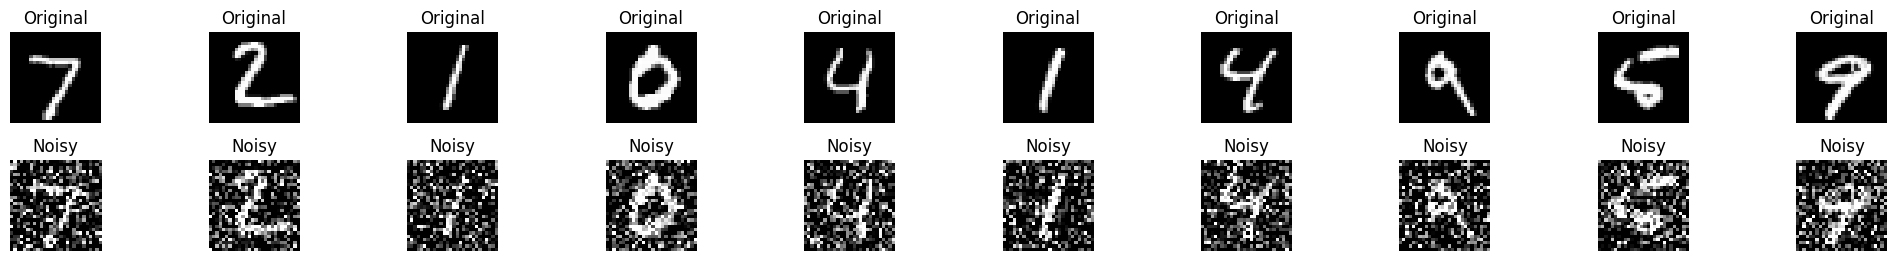

In [5]:
def plot_images(original, noisy, reconstructed=None, num_images=10):
    plt.figure(figsize=(num_images * 2, 6 if reconstructed is not None else 4))
    for i in range(num_images):
        # Original Image
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(original[i].reshape(IMG_WIDTH, IMG_HEIGHT), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Noisy Image
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy[i].reshape(IMG_WIDTH, IMG_HEIGHT), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        # Reconstructed Image (if provided)
        if reconstructed is not None:
            ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
            plt.imshow(reconstructed[i].reshape(IMG_WIDTH, IMG_HEIGHT), cmap='gray')
            plt.title("Reconstructed")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize a few samples from the test set
plot_images(x_test, x_test_noisy, num_images=10)


## 2. Autoencoder Model Definition

We will define a convolutional autoencoder model. The encoder will reduce the input image to a latent space representation, and the decoder will reconstruct the image from this representation. The model will be compiled with the Adam optimizer and mean squared error loss, as it's a regression task (reconstructing pixel values).

In [6]:
from tensorflow.keras import layers, models

# Define the Encoder
def build_encoder(input_shape):
    input_img = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
    return models.Model(input_img, encoded, name="encoder")

# Define the Decoder
def build_decoder(encoded_shape, output_shape):
    latent_input = layers.Input(shape=encoded_shape)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(latent_input)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(output_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)
    return models.Model(latent_input, decoded, name="decoder")

# Build the Autoencoder
input_shape = (IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS)
encoder = build_encoder(input_shape)
decoder = build_decoder(encoder.output.shape[1:], input_shape)

autoencoder_input = layers.Input(shape=input_shape)
encoded_output = encoder(autoencoder_input)
decoded_output = decoder(encoded_output)

autoencoder = models.Model(autoencoder_input, decoded_output, name="autoencoder")

# Compile the Autoencoder with Adam optimizer
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 7, 7, 64)       │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        55,681 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Autoencoder

Now, we will train the autoencoder using the noisy images as input and the clean images as targets. We will use the validation set to monitor the model's performance during training.

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 207ms/step - loss: 0.1131 - val_loss: 0.1117
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 204ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 213ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 231ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 133s 208ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 207ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - loss: 0.1121 - val_loss: 0.1117
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 206ms/step - loss: 0.1121 - val_loss: 0.1117


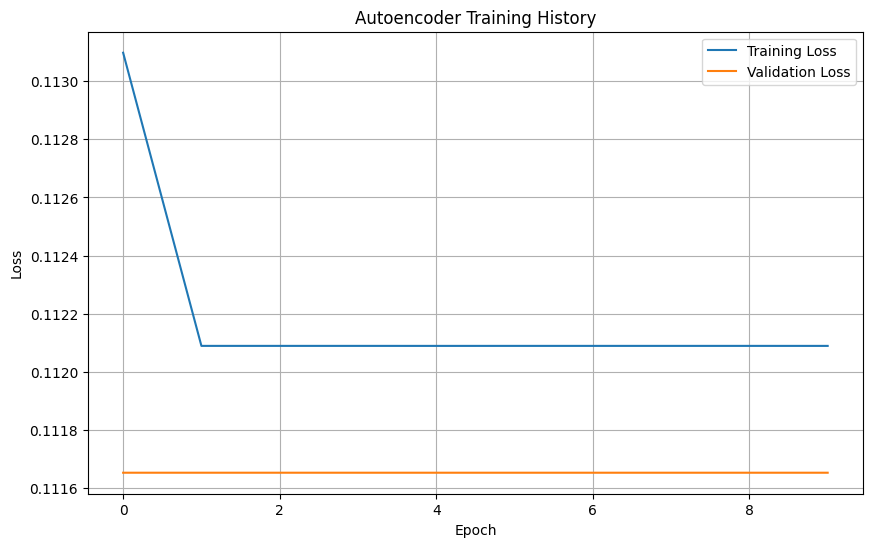

In [7]:
epochs = 10
batch_size = 128

history = autoencoder.fit(
    x_train_noisy, x_train_clean, # Input noisy, output clean
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_val_noisy, x_val_clean)
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 4. Evaluate and Visualize Results

Finally, we will use the trained autoencoder to denoise images from the test set and compare the results with the original clean images and the noisy inputs.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


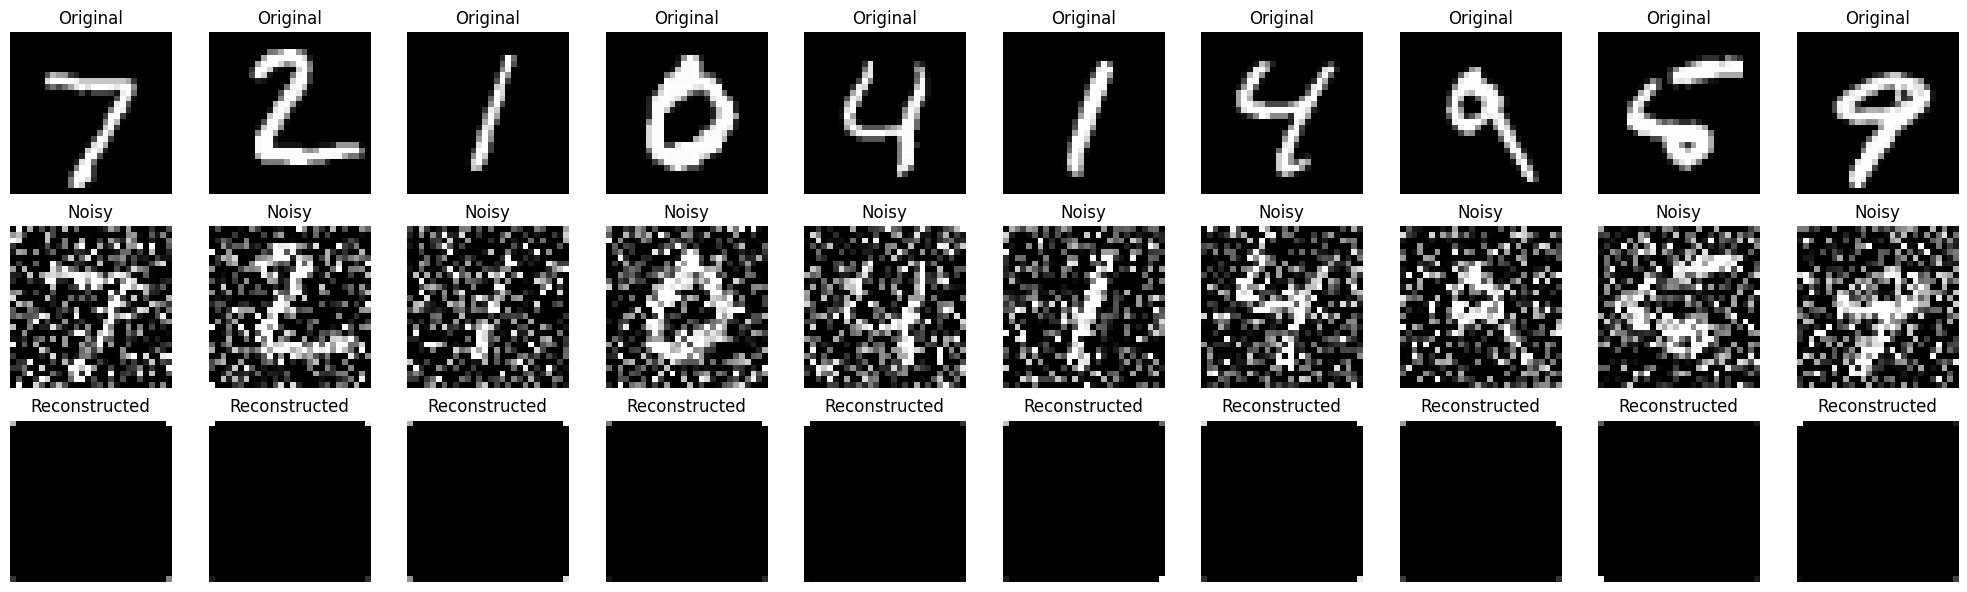

In [9]:
# Predict on test set
denoised_images = autoencoder.predict(x_test_noisy)

# Visualize the results
plot_images(x_test, x_test_noisy, denoised_images, num_images=10)

## 4. Evaluate and Visualize Results

Finally, we will use the trained autoencoder to denoise images from the test set and compare the results with the original clean images and the noisy inputs.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


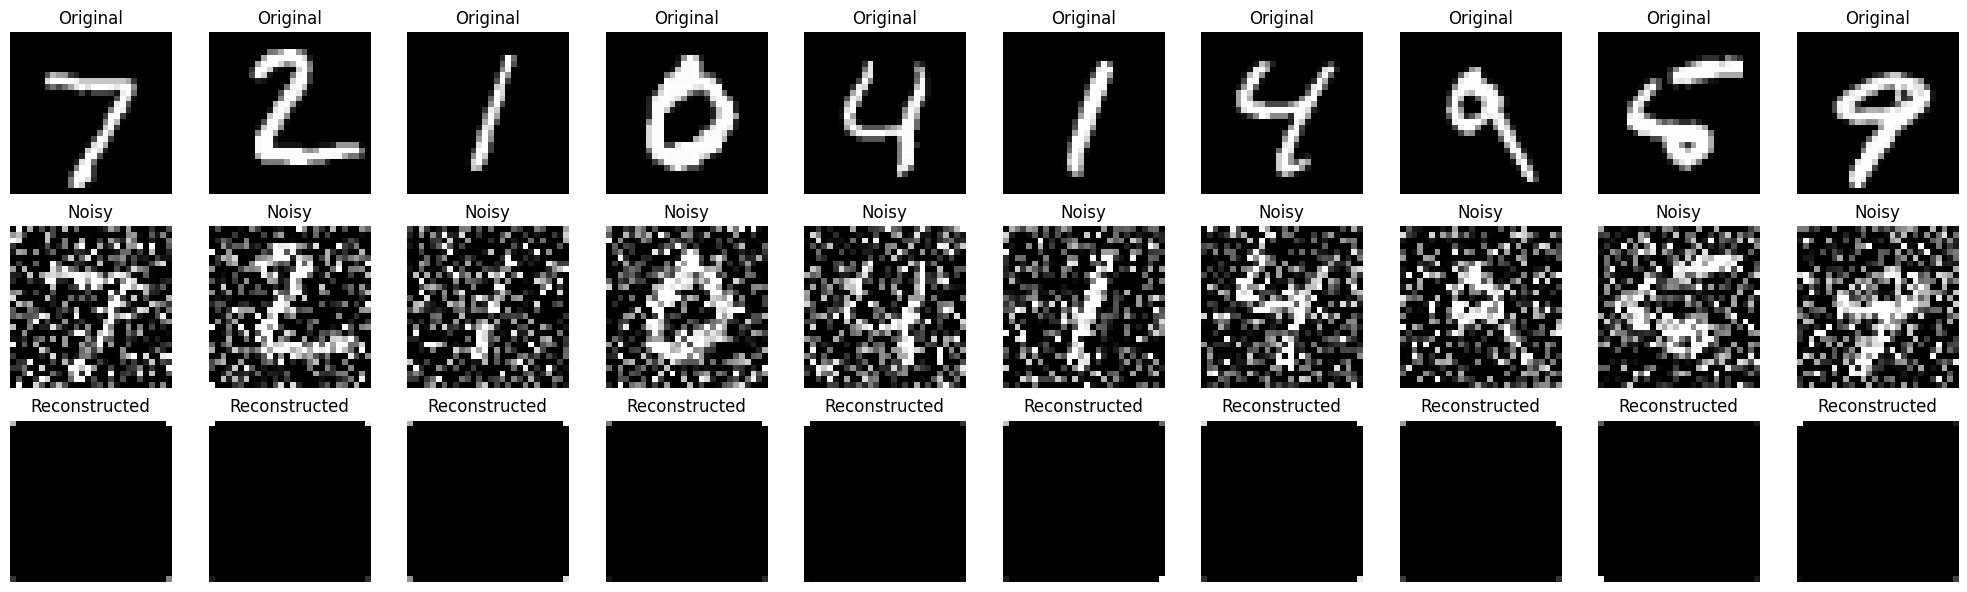

In [8]:
# Predict on test set
denoised_images = autoencoder.predict(x_test_noisy)

# Visualize the results
plot_images(x_test, x_test_noisy, denoised_images, num_images=10)